# Part 1: Dataset Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [5]:
df.shape

(569, 30)

In [6]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [7]:
df["target"] = data.target

X = df.drop("target", axis=1) 
y = df["target"]               


In [8]:
print(df["target"].value_counts())

target
1    357
0    212
Name: count, dtype: int64


# Part 2: Baseline Model


In [21]:
from sklearn.model_selection import train_test_split,GridSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9385964912280702

Confusion Matrix:
[[39  4]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [19]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9385964912280702


## Overfitting
##### Training Accuracy: 1.00
##### Testing Accuracy: 0.90
##### Model memorized the training data.
##### Large gap between train and test performance.
##### Decision Trees with no depth limit often show this behavior.

# Part 3: Bagging Implementation


In [22]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Score: 0.9626373626373625


In [23]:
best_rf = grid_search.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test)

In [24]:
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9649122807017544

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [25]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 1.0
Test Accuracy : 0.9649122807017544


#### Decision Tree learns from the training data using one tree.

#### Random Forest learns using many decision trees and combines their predictions.

### Why Random Forest is better?
#### Less Overfitting
#### Decision Tree can memorize the training data.
#### Random Forest reduces this problem by averaging many trees.
#### Higher Accuracy
#### Many trees make better decisions than a single tree.
#### More Reliable
#### If one tree makes a mistake, other trees can correct it.

# Part 4: Boosting Implementation


### AdaBoost

In [26]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [27]:
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9736842105263158


In [32]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1 Score : 0.979


### Gradient Boosting


In [28]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [29]:
y_pred = gb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.956140350877193


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1 Score : 0.979


# Part 5: Visualization


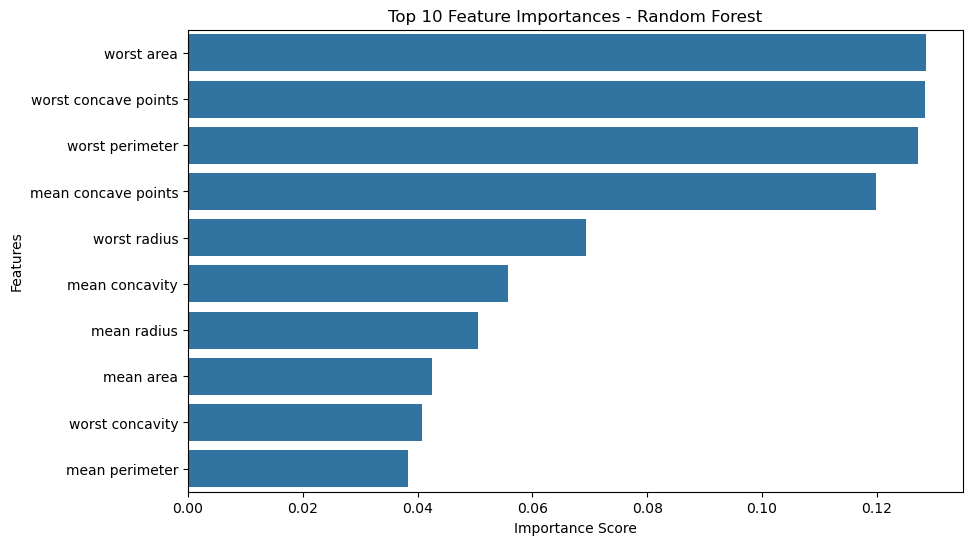

In [33]:

feature_importance = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': best_rf.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot Top 10 Features
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

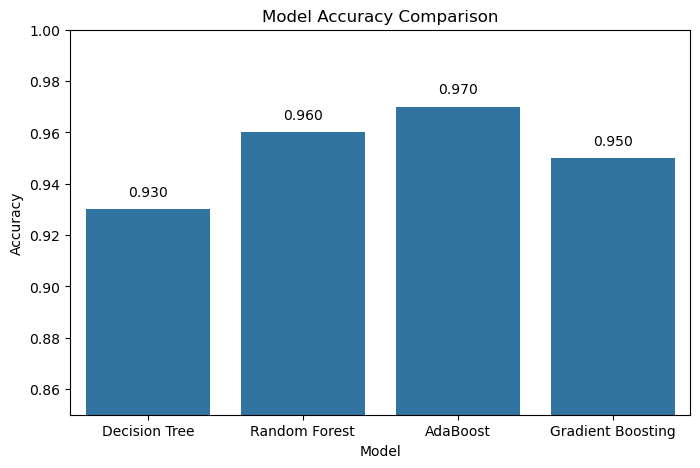

In [35]:
decision_tree_acc = 0.93
random_forest_acc = 0.96
adaboost_acc = 0.97
gradient_boost_acc = 0.95
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    'Decision Tree',
    'Random Forest',
    'AdaBoost',
    'Gradient Boosting'
]

accuracies = [
    decision_tree_acc,
    random_forest_acc,
    adaboost_acc,
    gradient_boost_acc
]

acc_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

plt.figure(figsize=(8,5))
sns.barplot(
    data=acc_df,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.show()

# Part 6: Model Comparison


In [39]:
# Decision Tree Predictions
dt_pred = model.predict(X_test)

# Random Forest Predictions
rf_pred = best_rf.predict(X_test)   # or rf_model.predict(X_test)

# AdaBoost Predictions
ada_pred = model.predict(X_test)

# Gradient Boosting Predictions
gb_pred = gb_model.predict(X_test)

In [40]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store results
results = []

# Decision Tree
results.append([
    "Decision Tree",
    accuracy_score(y_test, dt_pred),
    precision_score(y_test, dt_pred),
    recall_score(y_test, dt_pred),
    f1_score(y_test, dt_pred)
])

# Random Forest
results.append([
    "Random Forest",
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
])

# AdaBoost
results.append([
    "AdaBoost",
    accuracy_score(y_test, ada_pred),
    precision_score(y_test, ada_pred),
    recall_score(y_test, ada_pred),
    f1_score(y_test, ada_pred)
])

# Gradient Boosting
results.append([
    "Gradient Boost",
    accuracy_score(y_test, gb_pred),
    precision_score(y_test, gb_pred),
    recall_score(y_test, gb_pred),
    f1_score(y_test, gb_pred)
])

# Create DataFrame
comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

# Round values
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

print(comparison_df)

            Model  Accuracy  Precision  Recall  F1 Score
0   Decision Tree    0.9737     0.9722  0.9859    0.9790
1   Random Forest    0.9649     0.9589  0.9859    0.9722
2        AdaBoost    0.9737     0.9722  0.9859    0.9790
3  Gradient Boost    0.9561     0.9583  0.9718    0.9650


# Part 7: Conceptual Questions 

### 1. What is Ensemble Learning?

##### Ensemble Learning combines multiple machine learning models to make better predictions than a single model. It improves accuracy, robustness, and generalization.

### 2. Why does Bagging reduce variance?

##### Bagging trains multiple models on different random samples of the data and averages their predictions. This reduces the effect of individual model fluctuations and lowers variance.

### 3. Why does Boosting reduce bias?

##### Boosting trains models sequentially, where each new model focuses on correcting the mistakes of previous models. This helps the ensemble learn complex patterns and reduces bias.

### 4. Why is Boosting sequential?

##### In Boosting, each model depends on the errors made by the previous model. Therefore, models must be trained one after another rather than independently.

### 5. Difference between Random Forest and AdaBoost

##### Random Forest uses Bagging and builds many trees independently, while AdaBoost uses Boosting and builds trees sequentially. Random Forest mainly reduces variance, whereas AdaBoost mainly reduces bias.

### 6. When should we prefer Boosting over Bagging?

##### Choose Boosting when you need higher predictive accuracy and can tolerate longer training times. It is especially useful when the model is underfitting the data.

### 7. What are weak learners?

##### Weak learners are models that perform only slightly better than random guessing. In ensemble methods, many weak learners are combined to create a strong model.

### 8. Why are decision trees commonly used in ensemble methods?

##### Decision trees are fast, easy to train, and can capture complex patterns in data. They also work well with Bagging and Boosting techniques, making them ideal base learners.

# Part 8: Advanced Task 


In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("Accuracy :", round(xgb_accuracy,4))
print("Precision:", round(xgb_precision,4))
print("Recall   :", round(xgb_recall,4))
print("F1 Score :", round(xgb_f1,4))

Accuracy : 0.9561
Precision: 0.9583
Recall   : 0.9718
F1 Score : 0.965


In [42]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

print(comparison.round(4))

           Model  Accuracy  Precision  Recall  F1 Score
0  Random Forest    0.9649     0.9589  0.9859    0.9722
1        XGBoost    0.9561     0.9583  0.9718    0.9650


### Why is XGBoost often better than traditional boosting?

##### XGBoost improves upon traditional boosting by using advanced optimization techniques, regularization, and efficient handling of missing values. It trains faster, reduces overfitting, and often achieves higher accuracy on structured datasets